<a href="https://colab.research.google.com/github/GaioAugusto/Breast-Cancer-Detection/blob/main/APS360_Team_69_Main_File_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the second main file to test with new augmentations. Goes along with Dataset2

**Import Dataset**

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("paultimothymooney/breast-histopathology-images")
base_path = os.path.join(path, "IDC_regular_ps50_idx5")
print("Base path:", base_path)

100%|██████████| 3.10G/3.10G [00:41<00:00, 80.9MB/s]

Extracting files...


Base path: /root/.cache/kagglehub/datasets/paultimothymooney/breast-histopathology-images/versions/1/IDC_regular_ps50_idx5


**Import Libraries**

In [ ]:
import os
import shutil
import time
import random
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image, ImageDraw
from google.colab import drive
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_squared_error

**Dataset Check**

In [ ]:
cancer_images = []
non_cancer_images = []

for patient in os.listdir(base_path):
    patient_path = os.path.join(base_path, patient)
    if os.path.isdir(patient_path):
        for label in ['0', '1']:
            label_path = os.path.join(patient_path, label)
            if os.path.isdir(label_path):
                for file_name in os.listdir(label_path):
                    file_path = os.path.join(label_path, file_name)
                    if os.path.isfile(file_path):
                        if label == '0':
                            non_cancer_images.append(file_path)
                        elif label == '1':
                            cancer_images.append(file_path)

num_cancer = len(cancer_images)

# Randomly select an equal number of non-cancerous images
non_cancer_images = random.sample(non_cancer_images, num_cancer)

# Print the counts to confirm
print("Total non-cancer images (after balancing):", len(non_cancer_images))
print("Total cancer images:", len(cancer_images))

Total non-cancer images (after balancing): 78786
Total cancer images: 78786


**Split Data**

In [ ]:
def split_data(image_list, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2):
    # Shuffle the list to ensure random sampling
    random.shuffle(image_list)
    n = len(image_list)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)
    train = image_list[:train_end]
    val = image_list[train_end:val_end]
    test = image_list[val_end:]
    return train, val, test

# Split each class separately
train_non, val_non, test_non = split_data(non_cancer_images, 0.7, 0.1, 0.2)
train_cancer, val_cancer, test_cancer = split_data(cancer_images, 0.7, 0.1, 0.2)

**NEW AUGMENT DATA FUNCTION**

**Apply Augmentations**

In [ ]:
def augment_data(image_paths, label, train=False):
    if train:
        transform = transforms.Compose([
            transforms.RandomRotation(degrees=(-15, 15)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomResizedCrop(size=50, scale=(0.8, 1.0)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3))
        ])
    else:
        transform = transforms.Compose([
            transforms.Resize((50, 50)),
            transforms.ToTensor()
        ])

    augmented_data = []
    for img_path in image_paths:
        image = Image.open(img_path).convert('RGB')
        x = transform(image)
        augmented_data.append((x, label))
    return augmented_data

In [ ]:
train_non_aug = augment_data(train_non, label=0, train=True)
train_cancer_aug = augment_data(train_cancer, label=1, train=True)

val_non_aug = augment_data(val_non, label=0, train=False)
val_cancer_aug = augment_data(val_cancer, label=1, train=False)

test_non_aug = augment_data(test_non, label=0, train=False)
test_cancer_aug = augment_data(test_cancer, label=1, train=False)

train_dataset = train_non_aug + train_cancer_aug
val_dataset = val_non_aug + val_cancer_aug
test_dataset = test_non_aug + test_cancer_aug

print("Total train:", len(train_dataset))
print("Total val:", len(val_dataset))
print("Total test:", len(test_dataset))

Total train: 110300
Total val: 15756
Total test: 31516


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Training

In [ ]:
def get_accuracy(model, data_subset):
    correct = 0
    total = 0

    data_loader = DataLoader(data_subset, batch_size=1024, shuffle=True, num_workers=4)

    for imgs, labels in data_loader:
        # Move data and model to GPU if available
        if torch.cuda.is_available():
            imgs = imgs.cuda()
            labels = labels.cuda()
            model = model.cuda()

        output = model(imgs)

        pred = output.max(1, keepdim=True)[1]

        correct += pred.eq(labels.view_as(pred)).sum().item()

        total += imgs.shape[0]

    return correct / total

In [ ]:
def train(model, train_loader, val_loader,
       num_epochs=10, lr=0.001, print_stat=1,
          use_early_stopping=True):
    import time
    from tqdm import tqdm
    import matplotlib.pyplot as plt

    criterion = nn.BCEWithLogitsLoss()
    # Add weight decay to reduce overfitting
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    iters, losses = [], []
    train_acc, val_acc = [], []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.train()

    n = 0
    start_time = time.time()

    # Early stopping variables
    best_val_acc = 0.0
    epochs_no_improve = 0
    patience = 3

    for epoch in range(num_epochs):
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            imgs = imgs.to(device)
            labels = labels.to(device)

            out = model(imgs)
            loss = criterion(out, F.one_hot(labels, num_classes=2).float())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            iters.append(n)
            losses.append(loss.item())
            n += 1

        model.eval()

        train_epoch_acc = get_accuracy(model, train_loader.dataset)

        val_epoch_acc = get_accuracy(model, val_loader.dataset)

        train_acc.append(train_epoch_acc)
        val_acc.append(val_epoch_acc)

        # Print epoch stats
        current_lr = scheduler.get_last_lr()[0]
        avg_time_per_epoch = (time.time() - start_time) / (epoch + 1)
        print(f"\nEpoch {epoch} Finished. LR={current_lr:.6f}")
        print(f"  Train Accuracy:      {train_epoch_acc:.4f}")
        print(f"  Validation Accuracy: {val_epoch_acc:.4f}")
        print(f"  Time per Epoch:      {avg_time_per_epoch:6.2f}s")

        model.train()

        scheduler.step()


        if use_early_stopping:
            if val_epoch_acc > best_val_acc:
                best_val_acc = val_epoch_acc
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"Early stopping on epoch {epoch} (no improvement in {patience} epochs)!")
                    break

    end_time = time.time()

    if print_stat:
        plt.figure()
        plt.title("Training Loss Curve")
        plt.plot(iters, losses, label="Train Loss")
        plt.xlabel("Iterations")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

        plt.figure()
        plt.title("Accuracy per Epoch")
        plt.plot(range(len(train_acc)), train_acc, label="Train Acc")
        plt.plot(range(len(val_acc)), val_acc, label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

        print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
        print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
        total_time = end_time - start_time
        print(f"Total Time: {total_time:.2f}s")
        print(f"Time per Epoch: {total_time / (epoch + 1):.2f}s")

# Model

In [ ]:
class BreastNet(nn.Module):
    def __init__(self):
        super(BreastNet, self).__init__()
        self.name = "BreastNet"

        # 4 Convolutional Blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.bn_conv1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn_conv2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.bn_conv3 = nn.BatchNorm2d(128)

        # New 4th conv block
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3)
        self.bn_conv4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)

        self.final_spatial_dim = self.compute_feature_map_size(50)

        # Increase FC dimension for more capacity
        self.fc1 = nn.Linear(256 * self.final_spatial_dim * self.final_spatial_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(512, 2)

        self.activation = nn.SiLU()

    def compute_feature_map_size(self, input_size):
        size = (input_size - 3 + 1) // 2
        size = (size - 3 + 1) // 2
        size = (size - 3 + 1) // 2
        size = (size - 3 + 1) // 2
        return size

    def forward(self, x):
        x = self.pool(self.activation(self.bn_conv1(self.conv1(x))))
        x = self.pool(self.activation(self.bn_conv2(self.conv2(x))))
        x = self.pool(self.activation(self.bn_conv3(self.conv3(x))))

        # 4th conv block
        x = self.pool(self.activation(self.bn_conv4(self.conv4(x))))

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully Connected part
        x = self.bn1(self.fc1(x))
        x = self.dropout(self.activation(x))
        x = self.fc2(x)
        return x

Epoch 1/10: 100%|██████████| 1518/1518 [00:16<00:00, 91.60it/s]



Epoch 0 Finished. LR=0.001000
  Train Accuracy:      0.8253
  Validation Accuracy: 0.8347
  Time per Epoch:       26.36s


Epoch 2/10: 100%|██████████| 1518/1518 [00:15<00:00, 97.21it/s]



Epoch 1 Finished. LR=0.001000
  Train Accuracy:      0.7711
  Validation Accuracy: 0.7805
  Time per Epoch:       25.85s


Epoch 3/10: 100%|██████████| 1518/1518 [00:15<00:00, 97.39it/s]


...


Epoch 3 Finished. LR=0.000500
  Train Accuracy:      0.8463
  Validation Accuracy: 0.8525
  Time per Epoch:       25.66s


Epoch 5/10: 100%|██████████| 1518/1518 [00:15<00:00, 95.57it/s]



Epoch 4 Finished. LR=0.000500
  Train Accuracy:      0.8430
  Validation Accuracy: 0.8406
  Time per Epoch:       25.65s


Epoch 6/10: 100%|██████████| 1518/1518 [00:16<00:00, 93.82it/s] 



Epoch 5 Finished. LR=0.000500
  Train Accuracy:      0.8461
  Validation Accuracy: 0.8409
  Time per Epoch:       25.71s
Early stopping on epoch 5 (no improvement in 3 epochs)!


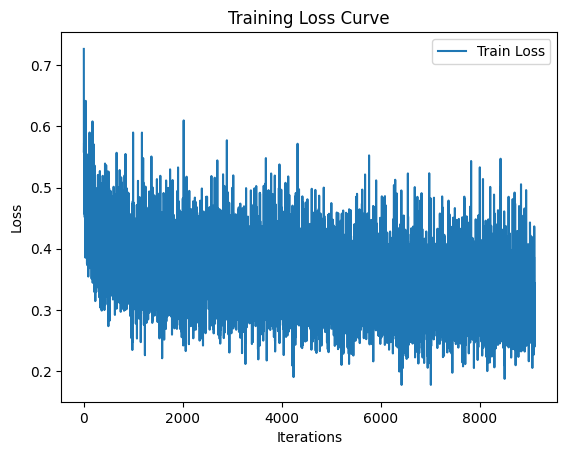

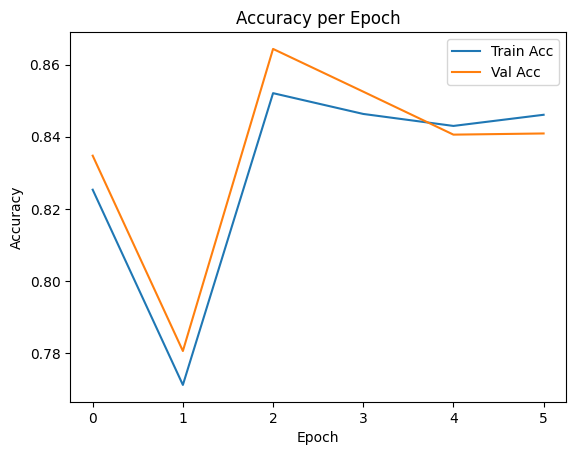

Final Training Accuracy: 0.8461
Final Validation Accuracy: 0.8409
Total Time: 154.25s
Time per Epoch: 25.71s


In [ ]:
breastnet = BreastNet()
train(model=breastnet, train_loader=train_loader, val_loader=val_loader, print_stat=1)

## The result above was achieved with learning rate 0.001 and batch size 128

## Here, I changed the batch size to 256 and learning rate to 0.0005 to try to reduce noise. Performance improved

Epoch 1/10: 100%|██████████| 759/759 [00:14<00:00, 50.84it/s]



Epoch 0 Finished. LR=0.000500
  Train Accuracy:      0.6856
  Validation Accuracy: 0.6795
  Time per Epoch:       24.76s


Epoch 2/10: 100%|██████████| 759/759 [00:14<00:00, 50.87it/s]



Epoch 1 Finished. LR=0.000500
  Train Accuracy:      0.7511
  Validation Accuracy: 0.7351
  Time per Epoch:       24.74s


Epoch 3/10: 100%|██████████| 759/759 [00:14<00:00, 51.00it/s]


...


Epoch 5 Finished. LR=0.000250
  Train Accuracy:      0.8138
  Validation Accuracy: 0.7859
  Time per Epoch:       24.76s


Epoch 7/10: 100%|██████████| 759/759 [00:14<00:00, 51.16it/s]



Epoch 6 Finished. LR=0.000125
  Train Accuracy:      0.8902
  Validation Accuracy: 0.8537
  Time per Epoch:       24.74s


Epoch 8/10: 100%|██████████| 759/759 [00:15<00:00, 50.40it/s]



Epoch 7 Finished. LR=0.000125
  Train Accuracy:      0.8963
  Validation Accuracy: 0.8513
  Time per Epoch:       24.76s
Early stopping on epoch 7 (no improvement in 3 epochs)!


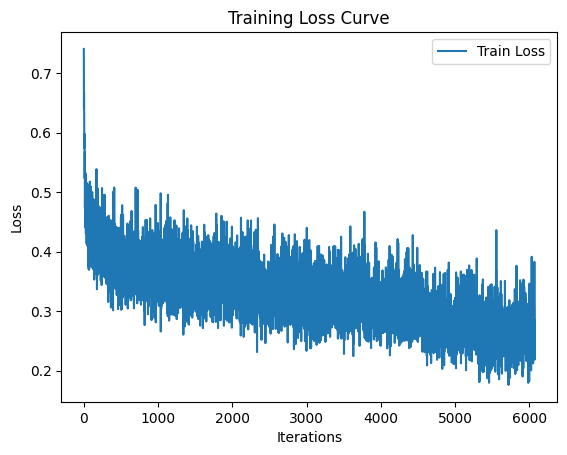

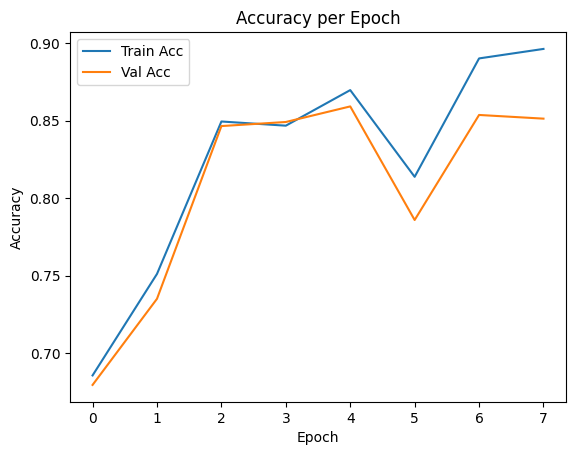

Final Training Accuracy: 0.8963
Final Validation Accuracy: 0.8513
Total Time: 198.04s
Time per Epoch: 24.76s


In [ ]:
breastnet2 = BreastNet()
train(model=breastnet2, train_loader=train_loader, val_loader=val_loader,lr=0.0005, print_stat=1)

# I will make changes to the training function

In [ ]:
def train(model, train_loader, val_loader,
       num_epochs=30, lr=0.001, print_stat=1,
          use_early_stopping=True):
    import time
    from tqdm import tqdm
    import matplotlib.pyplot as plt

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # LR Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.train()

    iters, losses = [], []
    train_acc, val_acc = [], []

    n = 0
    start_time = time.time()

    # Early stopping setup
    best_val_acc = 0.0
    epochs_no_improve = 0
    patience = 7

    for epoch in range(num_epochs):
        # Training loop
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            iters.append(n)
            losses.append(loss.item())
            n += 1

        # Evaluation
        model.eval()

        train_epoch_acc = get_accuracy(model, train_loader.dataset)
        val_epoch_acc = get_accuracy(model, val_loader.dataset)

        train_acc.append(train_epoch_acc)
        val_acc.append(val_epoch_acc)

        print(f"\nEpoch {epoch} Finished.")
        print(f"  Train Accuracy:      {train_epoch_acc:.4f}")
        print(f"  Validation Accuracy: {val_epoch_acc:.4f}")

        scheduler.step(val_epoch_acc)

        if use_early_stopping:
            if val_epoch_acc > best_val_acc:
                best_val_acc = val_epoch_acc
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(f"Early stopping on epoch {epoch} (no improvement in {patience} epochs)!")
                    break

        model.train()

    end_time = time.time()

    if print_stat:
        plt.figure()
        plt.title("Training Loss Curve")
        plt.plot(iters, losses, label="Train Loss")
        plt.xlabel("Iterations")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

        plt.figure()
        plt.title("Accuracy per Epoch")
        plt.plot(range(len(train_acc)), train_acc, label="Train Acc")
        plt.plot(range(len(val_acc)), val_acc, label="Val Acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()

        print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
        print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
        total_time = end_time - start_time
        print(f"Total Time: {total_time:.2f}s")
        print(f"Time per Epoch: {total_time / (epoch + 1):.2f}s")

Epoch 1/25: 100%|██████████| 759/759 [00:14<00:00, 50.86it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.8259
  Validation Accuracy: 0.8319


Epoch 2/25: 100%|██████████| 759/759 [00:15<00:00, 50.42it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8411
  Validation Accuracy: 0.8509


Epoch 3/25: 100%|██████████| 759/759 [00:15<00:00, 50.31it/s]


...


Epoch 8 Finished.
  Train Accuracy:      0.8830
  Validation Accuracy: 0.8568


Epoch 10/25: 100%|██████████| 759/759 [00:15<00:00, 50.01it/s]



Epoch 9 Finished.
  Train Accuracy:      0.8917
  Validation Accuracy: 0.8494


Epoch 11/25: 100%|██████████| 759/759 [00:15<00:00, 50.02it/s]



Epoch 10 Finished.
  Train Accuracy:      0.9015
  Validation Accuracy: 0.8460
Early stopping on epoch 10 (no improvement in 5 epochs)!


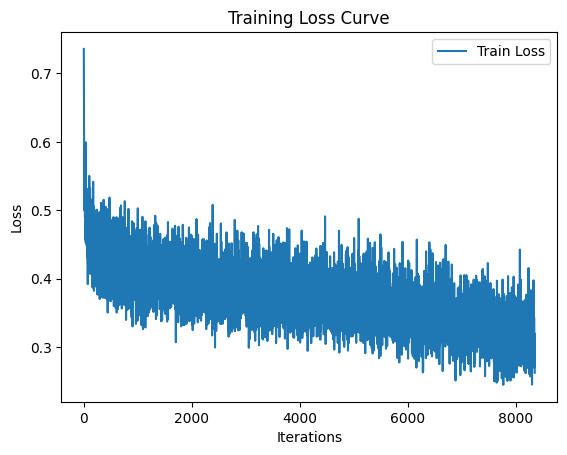

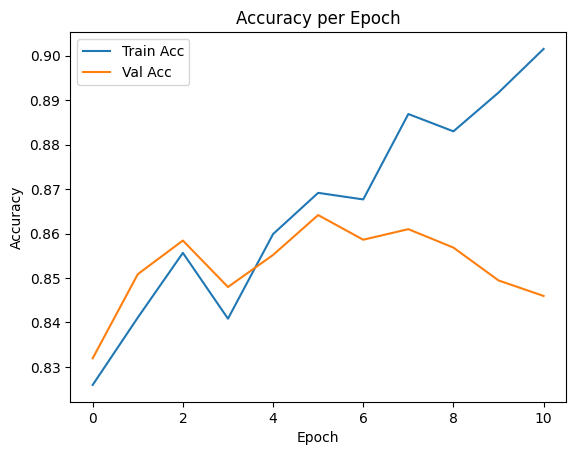

Final Training Accuracy: 0.9015
Final Validation Accuracy: 0.8460
Total Time: 275.87s
Time per Epoch: 25.08s


In [ ]:
breastnet5 = BreastNet()
train(model=breastnet5, train_loader=train_loader, val_loader=val_loader,lr=0.0005, print_stat=1)

# Tuning batch size

Epoch 1/25: 100%|██████████| 1724/1724 [00:12<00:00, 136.82it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.8076
  Validation Accuracy: 0.8210


Epoch 2/25: 100%|██████████| 1724/1724 [00:12<00:00, 138.75it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8192
  Validation Accuracy: 0.8352


Epoch 3/25: 100%|██████████| 1724/1724 [00:12<00:00, 135.98it/s]


...


Epoch 4 Finished.
  Train Accuracy:      0.8145
  Validation Accuracy: 0.8172


Epoch 6/25: 100%|██████████| 1724/1724 [00:12<00:00, 133.40it/s]



Epoch 5 Finished.
  Train Accuracy:      0.8110
  Validation Accuracy: 0.8238


Epoch 7/25: 100%|██████████| 1724/1724 [00:12<00:00, 135.13it/s]



Epoch 6 Finished.
  Train Accuracy:      0.8133
  Validation Accuracy: 0.8206
Early stopping on epoch 6 (no improvement in 5 epochs)!


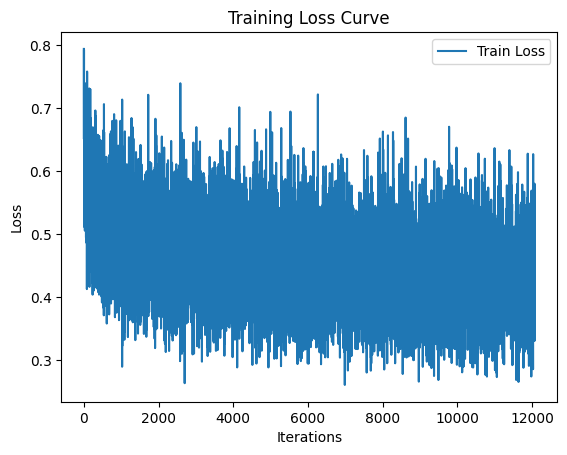

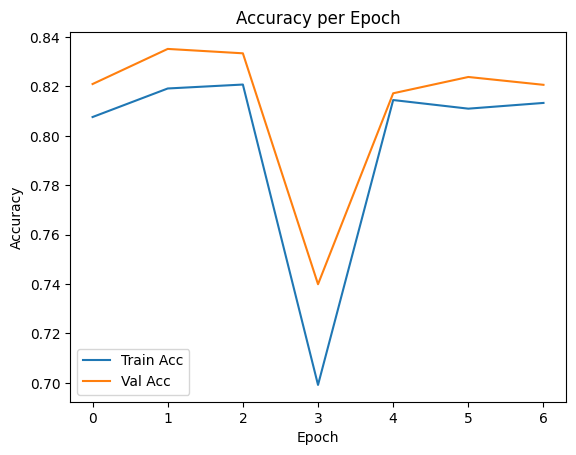

Final Training Accuracy: 0.8133
Final Validation Accuracy: 0.8206
Total Time: 126.67s
Time per Epoch: 18.10s


In [ ]:
# Batch size 64
breastnet6 = BreastNet()
train(model=breastnet6, train_loader=train_loader, val_loader=val_loader,lr=0.0005, print_stat=1)

Epoch 1/25: 100%|██████████| 862/862 [00:09<00:00, 91.10it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.6388
  Validation Accuracy: 0.6058


Epoch 2/25: 100%|██████████| 862/862 [00:09<00:00, 91.11it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8221
  Validation Accuracy: 0.8317


Epoch 3/25: 100%|██████████| 862/862 [00:09<00:00, 90.28it/s]


...


Epoch 8 Finished.
  Train Accuracy:      0.7881
  Validation Accuracy: 0.7812


Epoch 10/25: 100%|██████████| 862/862 [00:09<00:00, 90.43it/s]



Epoch 9 Finished.
  Train Accuracy:      0.8696
  Validation Accuracy: 0.8236


Epoch 11/25: 100%|██████████| 862/862 [00:09<00:00, 92.42it/s]



Epoch 10 Finished.
  Train Accuracy:      0.9000
  Validation Accuracy: 0.8281
Early stopping on epoch 10 (no improvement in 5 epochs)!


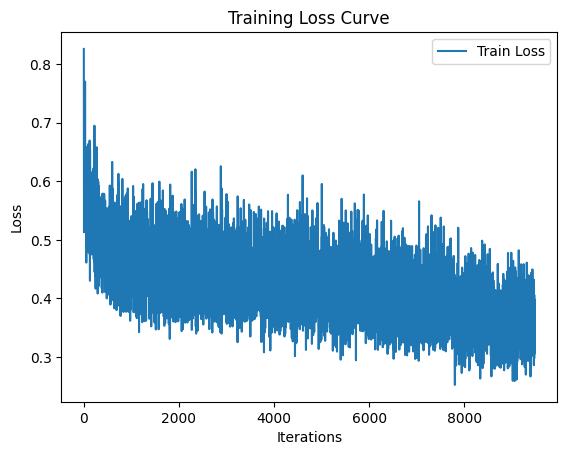

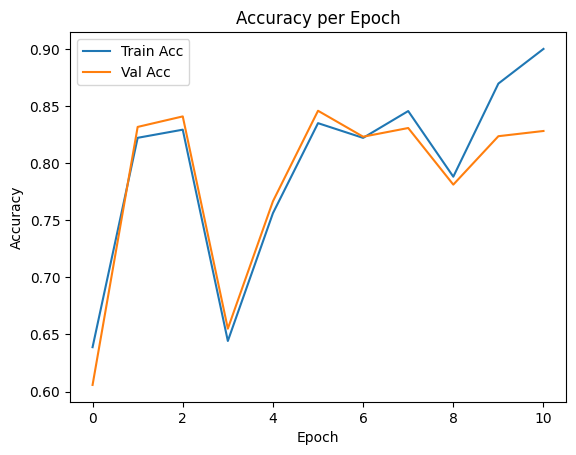

Final Training Accuracy: 0.9000
Final Validation Accuracy: 0.8281
Total Time: 164.04s
Time per Epoch: 14.91s


In [ ]:
# Batch size 128
breastnet7 = BreastNet()
train(model=breastnet7, train_loader=train_loader, val_loader=val_loader,lr=0.0005, print_stat=1)

Epoch 1/25: 100%|██████████| 431/431 [00:08<00:00, 49.99it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.7706
  Validation Accuracy: 0.7553


Epoch 2/25: 100%|██████████| 431/431 [00:08<00:00, 49.89it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8208
  Validation Accuracy: 0.8342


Epoch 3/25: 100%|██████████| 431/431 [00:08<00:00, 49.67it/s]


...


Epoch 8 Finished.
  Train Accuracy:      0.8691
  Validation Accuracy: 0.8286


Epoch 10/25: 100%|██████████| 431/431 [00:08<00:00, 50.08it/s]



Epoch 9 Finished.
  Train Accuracy:      0.9001
  Validation Accuracy: 0.8287


Epoch 11/25: 100%|██████████| 431/431 [00:08<00:00, 49.77it/s]



Epoch 10 Finished.
  Train Accuracy:      0.9033
  Validation Accuracy: 0.8329
Early stopping on epoch 10 (no improvement in 5 epochs)!


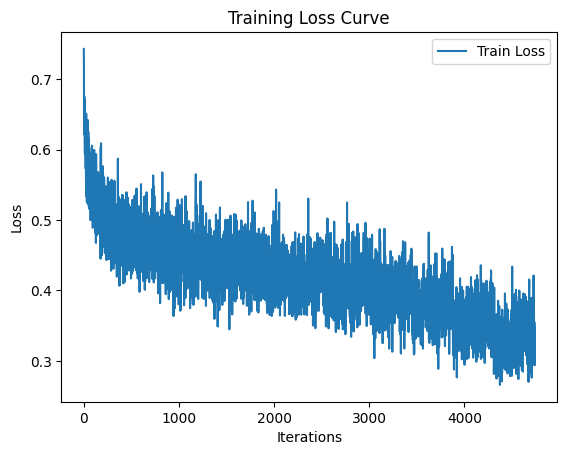

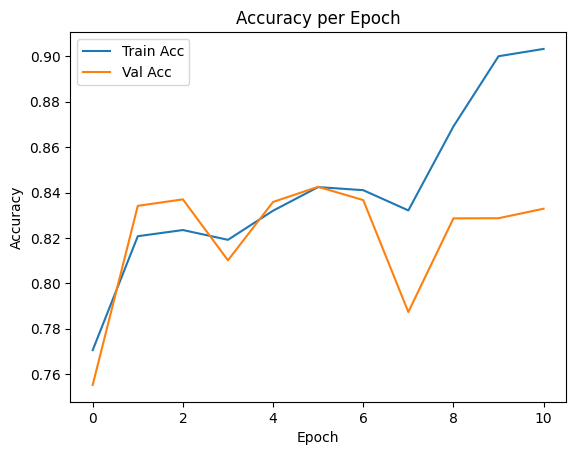

Final Training Accuracy: 0.9033
Final Validation Accuracy: 0.8329
Total Time: 155.02s
Time per Epoch: 14.09s


In [ ]:
# Batch size 256
breastnet8 = BreastNet()
train(model=breastnet8, train_loader=train_loader, val_loader=val_loader,lr=0.0005, print_stat=1)

Epoch 1/25: 100%|██████████| 216/216 [00:08<00:00, 25.09it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.8042
  Validation Accuracy: 0.8245


Epoch 2/25: 100%|██████████| 216/216 [00:08<00:00, 24.93it/s]



Epoch 1 Finished.
  Train Accuracy:      0.7910
  Validation Accuracy: 0.8085


Epoch 3/25: 100%|██████████| 216/216 [00:08<00:00, 24.81it/s]


...


Epoch 5 Finished.
  Train Accuracy:      0.8274
  Validation Accuracy: 0.8173


Epoch 7/25: 100%|██████████| 216/216 [00:08<00:00, 24.94it/s]



Epoch 6 Finished.
  Train Accuracy:      0.8610
  Validation Accuracy: 0.8290


Epoch 8/25: 100%|██████████| 216/216 [00:08<00:00, 25.09it/s]



Epoch 7 Finished.
  Train Accuracy:      0.8601
  Validation Accuracy: 0.8018
Early stopping on epoch 7 (no improvement in 5 epochs)!


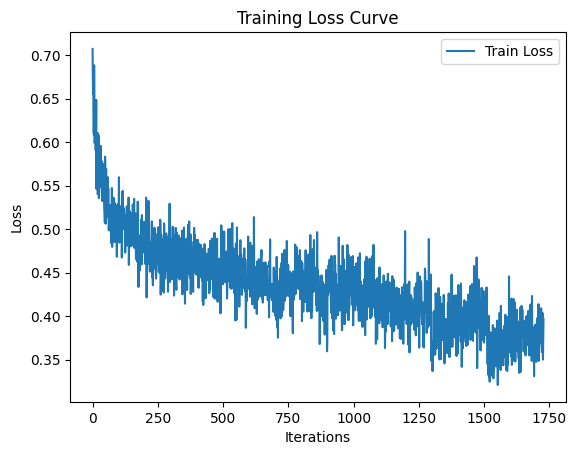

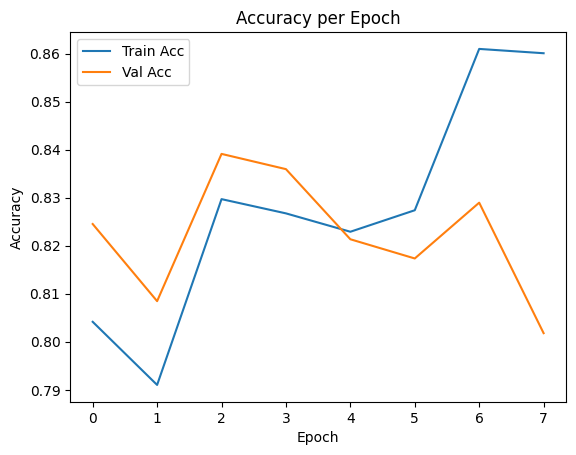

Final Training Accuracy: 0.8601
Final Validation Accuracy: 0.8018
Total Time: 113.11s
Time per Epoch: 14.14s


In [ ]:
# Batch size 512
breastnet9 = BreastNet()
train(model=breastnet9, train_loader=train_loader, val_loader=val_loader,lr=0.0005, print_stat=1)

Epoch 1/25: 100%|██████████| 108/108 [00:08<00:00, 12.10it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.7789
  Validation Accuracy: 0.8111


Epoch 2/25: 100%|██████████| 108/108 [00:08<00:00, 12.11it/s]



Epoch 1 Finished.
  Train Accuracy:      0.7457
  Validation Accuracy: 0.7793


Epoch 3/25: 100%|██████████| 108/108 [00:08<00:00, 12.06it/s]


...


Epoch 5 Finished.
  Train Accuracy:      0.8308
  Validation Accuracy: 0.8071


Epoch 7/25: 100%|██████████| 108/108 [00:08<00:00, 12.06it/s]



Epoch 6 Finished.
  Train Accuracy:      0.8481
  Validation Accuracy: 0.8043


Epoch 8/25: 100%|██████████| 108/108 [00:08<00:00, 12.09it/s]



Epoch 7 Finished.
  Train Accuracy:      0.8750
  Validation Accuracy: 0.8204
Early stopping on epoch 7 (no improvement in 5 epochs)!


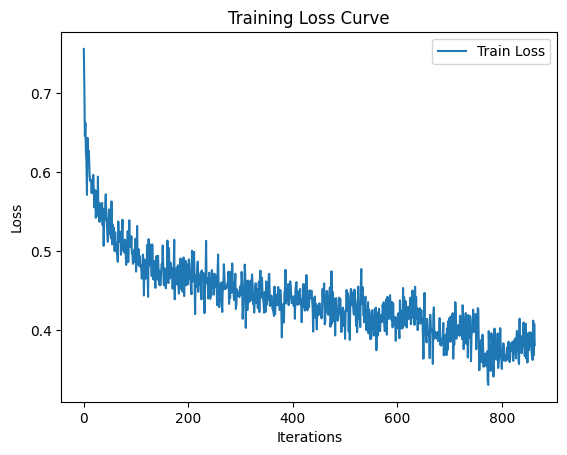

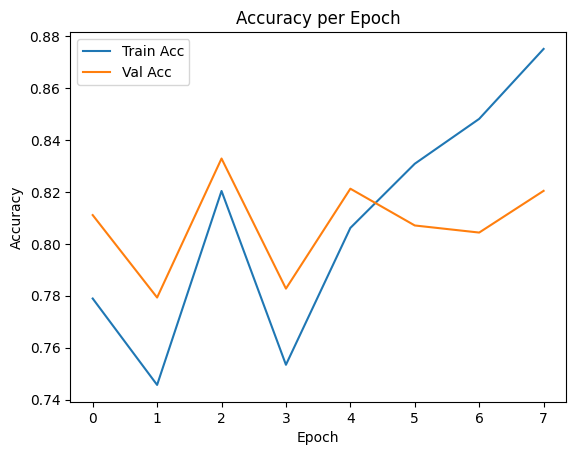

Final Training Accuracy: 0.8750
Final Validation Accuracy: 0.8204
Total Time: 115.48s
Time per Epoch: 14.44s


In [ ]:
# Batch size 1024
breastnet10 = BreastNet()
train(model=breastnet10, train_loader=train_loader, val_loader=val_loader,lr=0.0005, print_stat=1)

## Batch Size conclusions
64: 81.33 training; 82.06 validation; Epoch 10\
128: 90.00 training; 82.81 validation; Epoch 10; NO OVERFITTING\
256: 90.33 training; 83.29 validation; Epoch 10\
512: 86.01 training; 80.18 validation; Epoch 7; A LOT OF OVERFITTING\
1024: 87.5 training; 82.04 validation; Epoch 7

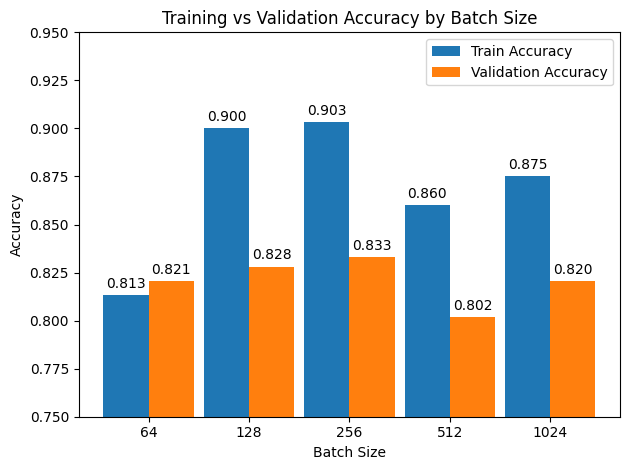

In [ ]:
results = {
    64:  {'train_acc': 0.8133, 'val_acc': 0.8206},
    128: {'train_acc': 0.9000, 'val_acc': 0.8281},
    256: {'train_acc': 0.9033, 'val_acc': 0.8329},
    512: {'train_acc': 0.8601, 'val_acc': 0.8018},
    1024: {'train_acc': 0.8750, 'val_acc': 0.8204}
}

batch_sizes = list(results.keys())
train_accuracies = [results[bs]['train_acc'] for bs in batch_sizes]
val_accuracies = [results[bs]['val_acc'] for bs in batch_sizes]

x = np.arange(len(batch_sizes))
width = 0.45

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy')
bars2 = ax.bar(x + width/2, val_accuracies, width, label='Validation Accuracy')


ax.set_ylabel('Accuracy')
ax.set_xlabel('Batch Size')
ax.set_title('Training vs Validation Accuracy by Batch Size')
ax.set_xticks(x)
ax.set_xticklabels(batch_sizes)
ax.set_ylim(0.75, 0.95)
ax.legend()


for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 128 and 256 are the best, but looking at the curves the 128 one is overfitting less so we'll stick with 128

# Next hyperparameter: Learning Rate

BreastNet7 used learning rate 0.0005

Epoch 1/25: 100%|██████████| 862/862 [00:09<00:00, 87.52it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.7857
  Validation Accuracy: 0.7480


Epoch 2/25: 100%|██████████| 862/862 [00:09<00:00, 86.44it/s]



Epoch 1 Finished.
  Train Accuracy:      0.7961
  Validation Accuracy: 0.8005


Epoch 3/25: 100%|██████████| 862/862 [00:09<00:00, 88.72it/s]


...


Epoch 7 Finished.
  Train Accuracy:      0.8503
  Validation Accuracy: 0.8019


Epoch 9/25: 100%|██████████| 862/862 [00:09<00:00, 90.14it/s]



Epoch 8 Finished.
  Train Accuracy:      0.8749
  Validation Accuracy: 0.8135


Epoch 10/25: 100%|██████████| 862/862 [00:09<00:00, 89.61it/s]



Epoch 9 Finished.
  Train Accuracy:      0.8840
  Validation Accuracy: 0.7892
Early stopping on epoch 9 (no improvement in 5 epochs)!


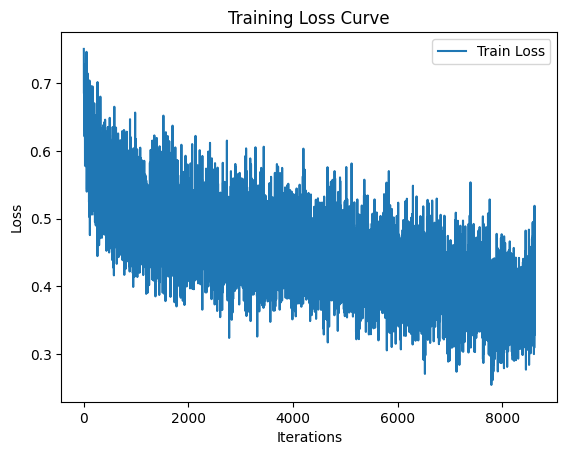

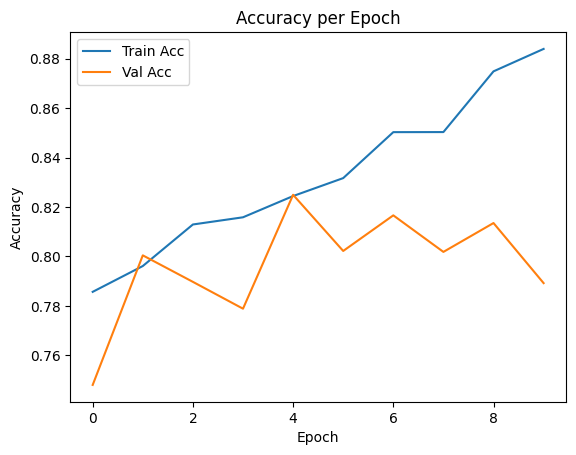

Final Training Accuracy: 0.8840
Final Validation Accuracy: 0.7892
Total Time: 151.33s
Time per Epoch: 15.13s


In [ ]:
breastnet2 = BreastNet()
train(model=breastnet2, train_loader=train_loader, val_loader=val_loader,lr=0.00005, print_stat=1)

Epoch 1/25: 100%|██████████| 862/862 [00:09<00:00, 90.19it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.5749
  Validation Accuracy: 0.6218


Epoch 2/25: 100%|██████████| 862/862 [00:09<00:00, 89.21it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8003
  Validation Accuracy: 0.8094


Epoch 3/25: 100%|██████████| 862/862 [00:09<00:00, 89.67it/s]


...


Epoch 13 Finished.
  Train Accuracy:      0.7983
  Validation Accuracy: 0.8092


Epoch 15/25: 100%|██████████| 862/862 [00:09<00:00, 89.59it/s]



Epoch 14 Finished.
  Train Accuracy:      0.6860
  Validation Accuracy: 0.7027


Epoch 16/25: 100%|██████████| 862/862 [00:09<00:00, 88.33it/s]



Epoch 15 Finished.
  Train Accuracy:      0.7348
  Validation Accuracy: 0.7628
Early stopping on epoch 15 (no improvement in 5 epochs)!


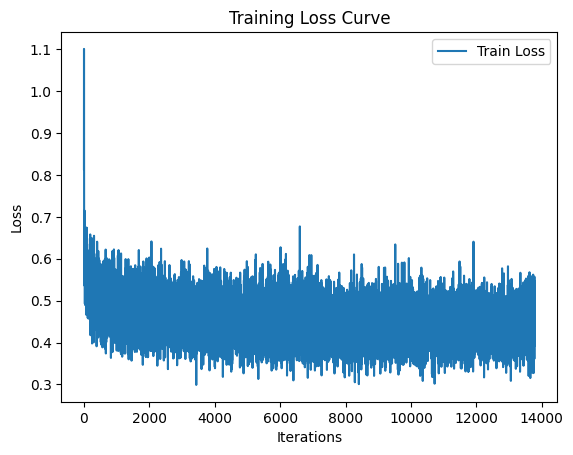

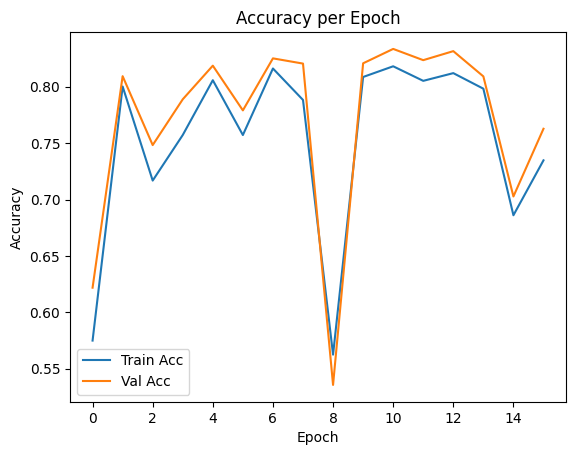

Final Training Accuracy: 0.7348
Final Validation Accuracy: 0.7628
Total Time: 241.10s
Time per Epoch: 15.07s


In [ ]:
breastnet3 = BreastNet()
train(model=breastnet3, train_loader=train_loader, val_loader=val_loader,lr=0.005, print_stat=1)

Epoch 1/25: 100%|██████████| 862/862 [00:09<00:00, 88.93it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.7734
  Validation Accuracy: 0.8065


Epoch 2/25: 100%|██████████| 862/862 [00:09<00:00, 87.14it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8123
  Validation Accuracy: 0.8238


Epoch 3/25: 100%|██████████| 862/862 [00:09<00:00, 89.63it/s]


...


Epoch 5 Finished.
  Train Accuracy:      0.8589
  Validation Accuracy: 0.8347


Epoch 7/25: 100%|██████████| 862/862 [00:09<00:00, 87.99it/s]



Epoch 6 Finished.
  Train Accuracy:      0.8409
  Validation Accuracy: 0.8180


Epoch 8/25: 100%|██████████| 862/862 [00:09<00:00, 89.23it/s]



Epoch 7 Finished.
  Train Accuracy:      0.8721
  Validation Accuracy: 0.8308
Early stopping on epoch 7 (no improvement in 5 epochs)!


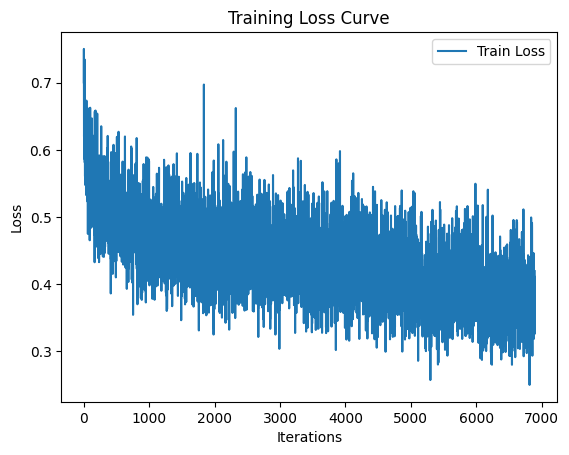

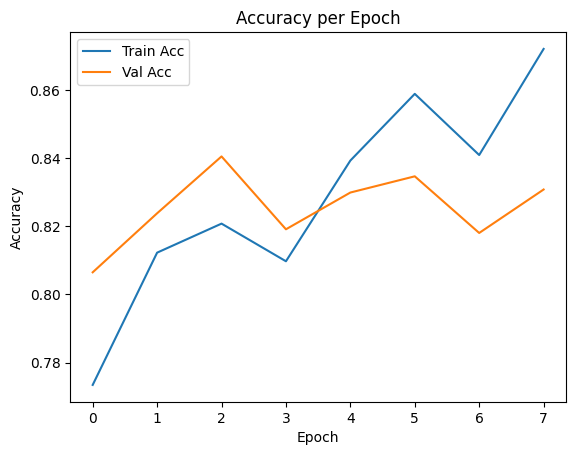

Final Training Accuracy: 0.8721
Final Validation Accuracy: 0.8308
Total Time: 121.88s
Time per Epoch: 15.23s


In [ ]:
breastnet4 = BreastNet()
train(model=breastnet4, train_loader=train_loader, val_loader=val_loader,lr=0.0003, print_stat=1)

Epoch 1/25: 100%|██████████| 862/862 [00:09<00:00, 87.76it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.7923
  Validation Accuracy: 0.8041


Epoch 2/25: 100%|██████████| 862/862 [00:09<00:00, 88.25it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8004
  Validation Accuracy: 0.8158


Epoch 3/25: 100%|██████████| 862/862 [00:09<00:00, 87.38it/s]


...


Epoch 6 Finished.
  Train Accuracy:      0.8741
  Validation Accuracy: 0.8295


Epoch 8/25: 100%|██████████| 862/862 [00:09<00:00, 88.48it/s]



Epoch 7 Finished.
  Train Accuracy:      0.8761
  Validation Accuracy: 0.8192


Epoch 9/25: 100%|██████████| 862/862 [00:09<00:00, 87.90it/s]



Epoch 8 Finished.
  Train Accuracy:      0.9210
  Validation Accuracy: 0.8203
Early stopping on epoch 8 (no improvement in 5 epochs)!


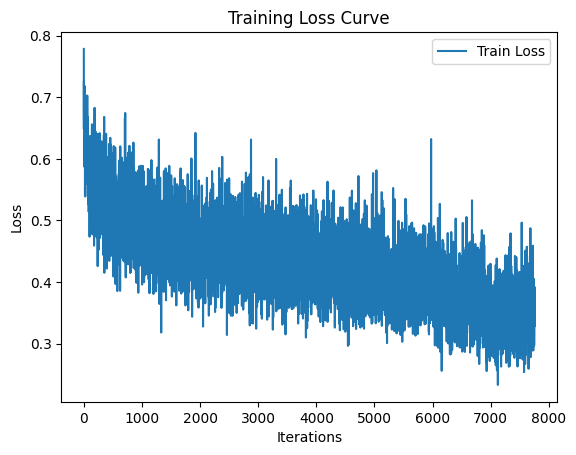

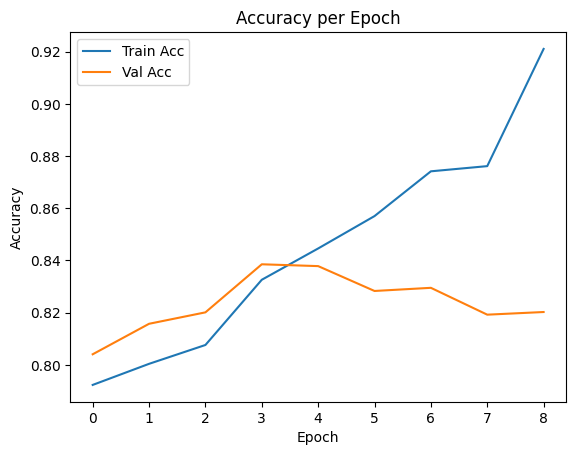

Final Training Accuracy: 0.9210
Final Validation Accuracy: 0.8203
Total Time: 137.45s
Time per Epoch: 15.27s


In [ ]:
breastnet5 = BreastNet()
train(model=breastnet5, train_loader=train_loader, val_loader=val_loader,lr=0.0001, print_stat=1)

Epoch 1/25: 100%|██████████| 862/862 [00:10<00:00, 84.97it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.7676
  Validation Accuracy: 0.8115


Epoch 2/25: 100%|██████████| 862/862 [00:09<00:00, 88.15it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8028
  Validation Accuracy: 0.8284


Epoch 3/25: 100%|██████████| 862/862 [00:09<00:00, 86.50it/s]


...


Epoch 16 Finished.
  Train Accuracy:      0.8311
  Validation Accuracy: 0.8293


Epoch 18/25: 100%|██████████| 862/862 [00:09<00:00, 88.48it/s]



Epoch 17 Finished.
  Train Accuracy:      0.8393
  Validation Accuracy: 0.8386


Epoch 19/25: 100%|██████████| 862/862 [00:09<00:00, 88.79it/s]



Epoch 18 Finished.
  Train Accuracy:      0.8531
  Validation Accuracy: 0.8398
Early stopping on epoch 18 (no improvement in 5 epochs)!


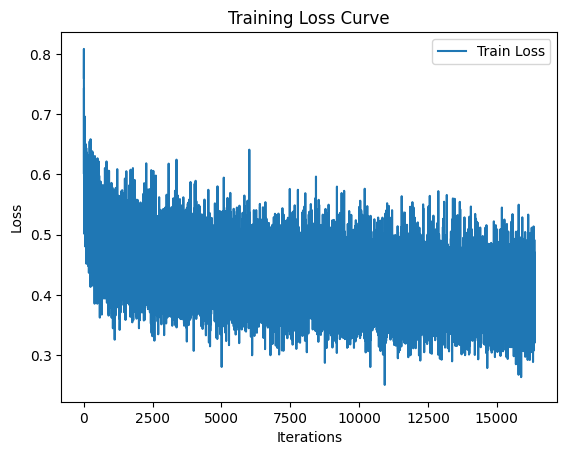

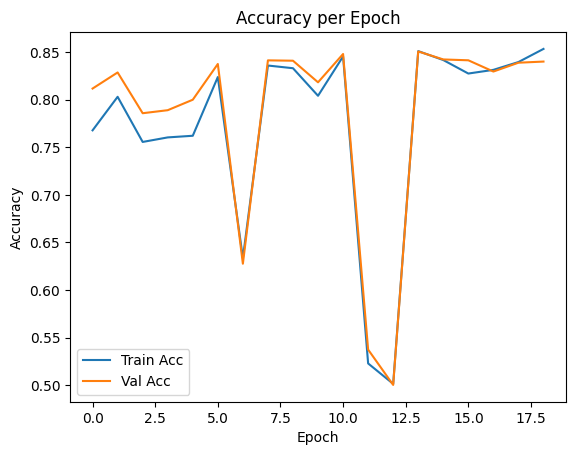

Final Training Accuracy: 0.8531
Final Validation Accuracy: 0.8398
Total Time: 291.49s
Time per Epoch: 15.34s


In [ ]:
breastnet6 = BreastNet()
train(model=breastnet6, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

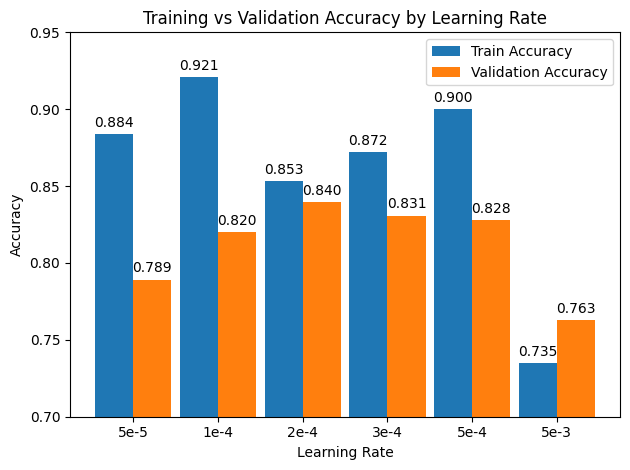

In [ ]:
results_lr = {
    "5e-5": {'train_acc': 0.8840, 'val_acc': 0.7892, 'num_epochs': 9},
    "1e-4":  {'train_acc': 0.9210, 'val_acc': 0.8203, 'num_epochs': 8},
    "2e-4": {'train_acc': 0.8531, 'val_acc': 0.8398, 'num_epochs': 18},
    "3e-4": {'train_acc': 0.8721, 'val_acc': 0.8308, 'num_epochs': 7},
    "5e-4":  {'train_acc': 0.9000, 'val_acc': 0.8281, 'num_epochs': 10},
    "5e-3": {'train_acc': 0.7348, 'val_acc': 0.7628, 'num_epochs': 15},
}

learning_rates = list(results_lr.keys())
train_accuracies = [results_lr[lr]['train_acc'] for lr in learning_rates]
val_accuracies = [results_lr[lr]['val_acc'] for lr in learning_rates]
num_epochs = [results_lr[lr]['num_epochs'] for lr in learning_rates]

x = np.arange(len(learning_rates))
width = 0.45

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy')
bars2 = ax.bar(x + width/2, val_accuracies, width, label='Validation Accuracy')


ax.set_ylabel('Accuracy')
ax.set_xlabel('Learning Rate')
ax.set_title('Training vs Validation Accuracy by Learning Rate')
ax.set_xticks(x)
ax.set_xticklabels(learning_rates)
ax.set_ylim(0.70, 0.95)
ax.legend()


for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

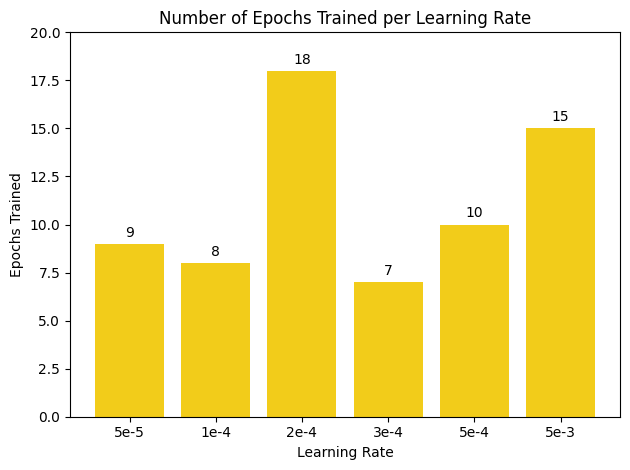

In [ ]:
num_epochs = [results_lr[lr]['num_epochs'] for lr in learning_rates]

x = np.arange(len(learning_rates))

fig, ax = plt.subplots()
bars = ax.bar(x, num_epochs, color=(0.95, 0.8, 0.1))

ax.set_ylabel('Epochs Trained')
ax.set_xlabel('Learning Rate')
ax.set_title('Number of Epochs Trained per Learning Rate')
ax.set_xticks(x)
ax.set_xticklabels(learning_rates)
ax.set_ylim(0, max(num_epochs) + 2)


for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Next step: Tuning dropout

## Currently we are doing 0.6 dropout, but we will try to lower that since the model is generalizing super well

Let's try 0.1

Epoch 1/30: 100%|██████████| 862/862 [00:09<00:00, 89.70it/s]



Epoch 0 Finished.
  Train Accuracy:      0.6942
  Validation Accuracy: 0.7300


Epoch 2/30: 100%|██████████| 862/862 [00:09<00:00, 86.62it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8137
  Validation Accuracy: 0.8214


Epoch 3/30: 100%|██████████| 862/862 [00:09<00:00, 88.88it/s]


...


Epoch 15 Finished.
  Train Accuracy:      0.8121
  Validation Accuracy: 0.7991


Epoch 17/30: 100%|██████████| 862/862 [00:09<00:00, 87.24it/s]



Epoch 16 Finished.
  Train Accuracy:      0.8296
  Validation Accuracy: 0.8086


Epoch 18/30: 100%|██████████| 862/862 [00:09<00:00, 86.75it/s]



Epoch 17 Finished.
  Train Accuracy:      0.7703
  Validation Accuracy: 0.7863
Early stopping on epoch 17 (no improvement in 7 epochs)!


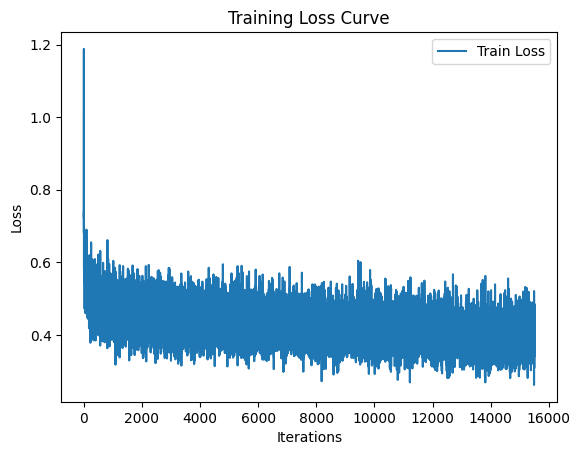

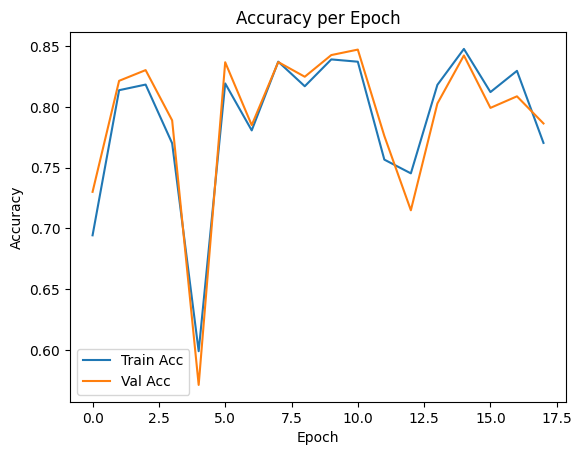

Final Training Accuracy: 0.7703
Final Validation Accuracy: 0.7863
Total Time: 278.35s
Time per Epoch: 15.46s


In [ ]:
# DROPOUT 0.1
breastnet4 = BreastNet()
train(model=breastnet4, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

Epoch 1/25: 100%|██████████| 862/862 [00:10<00:00, 78.56it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.6671
  Validation Accuracy: 0.6974


Epoch 2/25: 100%|██████████| 862/862 [00:09<00:00, 92.48it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8008
  Validation Accuracy: 0.8193


Epoch 3/25: 100%|██████████| 862/862 [00:09<00:00, 90.81it/s]


...


Epoch 17 Finished.
  Train Accuracy:      0.8396
  Validation Accuracy: 0.8312


Epoch 19/25: 100%|██████████| 862/862 [00:10<00:00, 85.14it/s]



Epoch 18 Finished.
  Train Accuracy:      0.8307
  Validation Accuracy: 0.8199


Epoch 20/25: 100%|██████████| 862/862 [00:09<00:00, 87.60it/s]



Epoch 19 Finished.
  Train Accuracy:      0.8636
  Validation Accuracy: 0.8454
Early stopping on epoch 19 (no improvement in 5 epochs)!


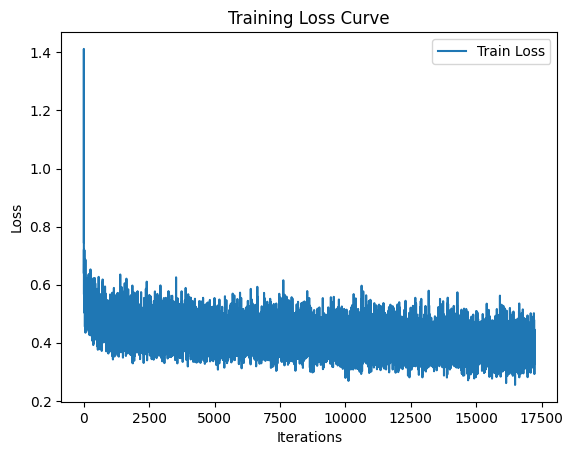

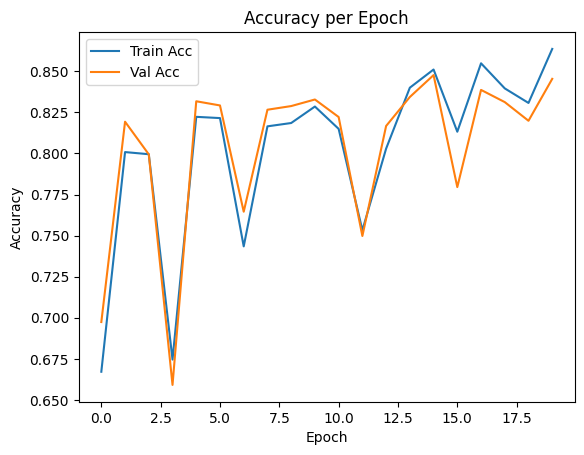

Final Training Accuracy: 0.8636
Final Validation Accuracy: 0.8454
Total Time: 309.81s
Time per Epoch: 15.49s


In [ ]:
# DROPOUT 0.2
breastnet2 = BreastNet()
train(model=breastnet2, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

Epoch 1/30: 100%|██████████| 862/862 [00:09<00:00, 89.53it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.7439
  Validation Accuracy: 0.7812


Epoch 2/30: 100%|██████████| 862/862 [00:09<00:00, 87.73it/s]



Epoch 1 Finished.
  Train Accuracy:      0.7447
  Validation Accuracy: 0.7683


Epoch 3/30: 100%|██████████| 862/862 [00:09<00:00, 87.70it/s]


...


Epoch 11 Finished.
  Train Accuracy:      0.8452
  Validation Accuracy: 0.8324


Epoch 13/30: 100%|██████████| 862/862 [00:09<00:00, 92.96it/s]



Epoch 12 Finished.
  Train Accuracy:      0.8488
  Validation Accuracy: 0.8427


Epoch 14/30: 100%|██████████| 862/862 [00:09<00:00, 93.04it/s]



Epoch 13 Finished.
  Train Accuracy:      0.8354
  Validation Accuracy: 0.8340
Early stopping on epoch 13 (no improvement in 5 epochs)!


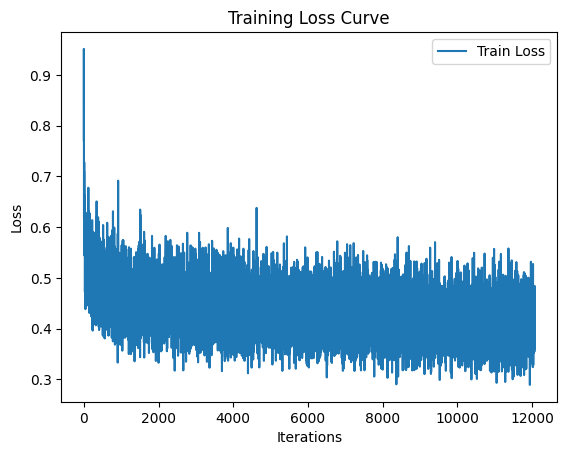

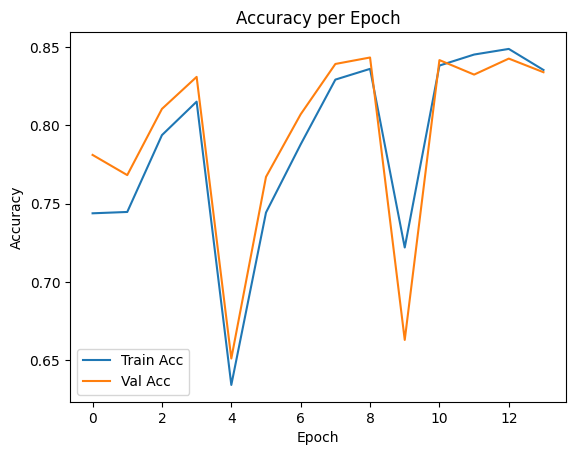

Final Training Accuracy: 0.8354
Final Validation Accuracy: 0.8340
Total Time: 213.13s
Time per Epoch: 15.22s


In [ ]:
# DROPOUT 0.3
breastnet5 = BreastNet()
train(model=breastnet5, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

Epoch 1/30: 100%|██████████| 862/862 [00:09<00:00, 92.70it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.5719
  Validation Accuracy: 0.5545


Epoch 2/30: 100%|██████████| 862/862 [00:09<00:00, 94.26it/s]



Epoch 1 Finished.
  Train Accuracy:      0.7176
  Validation Accuracy: 0.7496


Epoch 3/30: 100%|██████████| 862/862 [00:09<00:00, 93.95it/s]


...


Epoch 17 Finished.
  Train Accuracy:      0.8153
  Validation Accuracy: 0.8047


Epoch 19/30: 100%|██████████| 862/862 [00:09<00:00, 92.44it/s]



Epoch 18 Finished.
  Train Accuracy:      0.8538
  Validation Accuracy: 0.8413


Epoch 20/30: 100%|██████████| 862/862 [00:09<00:00, 92.68it/s]



Epoch 19 Finished.
  Train Accuracy:      0.8462
  Validation Accuracy: 0.8093
Early stopping on epoch 19 (no improvement in 5 epochs)!


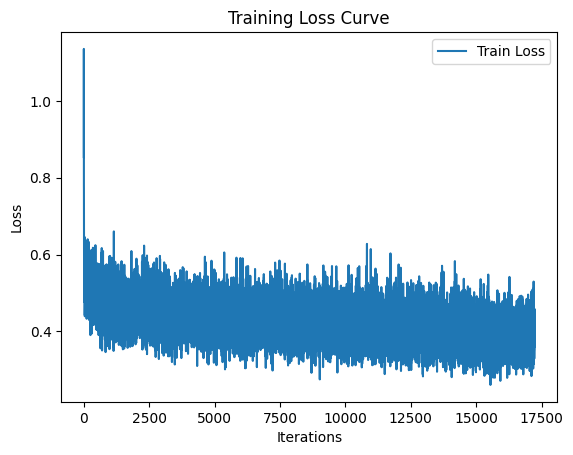

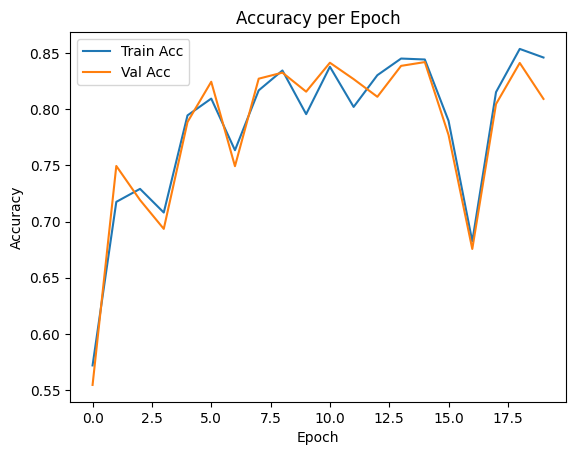

Final Training Accuracy: 0.8462
Final Validation Accuracy: 0.8093
Total Time: 304.01s
Time per Epoch: 15.20s


In [ ]:
# DROPOUT 0.4
breastnet6 = BreastNet()
train(model=breastnet6, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

Epoch 1/30: 100%|██████████| 862/862 [00:09<00:00, 93.67it/s]



Epoch 0 Finished.
  Train Accuracy:      0.5544
  Validation Accuracy: 0.5347


Epoch 2/30: 100%|██████████| 862/862 [00:09<00:00, 92.54it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8146
  Validation Accuracy: 0.8298


Epoch 3/30: 100%|██████████| 862/862 [00:09<00:00, 91.80it/s]


...


Epoch 6 Finished.
  Train Accuracy:      0.8147
  Validation Accuracy: 0.8230


Epoch 8/30: 100%|██████████| 862/862 [00:09<00:00, 91.95it/s]



Epoch 7 Finished.
  Train Accuracy:      0.6858
  Validation Accuracy: 0.7041


Epoch 9/30: 100%|██████████| 862/862 [00:09<00:00, 93.62it/s]



Epoch 8 Finished.
  Train Accuracy:      0.8189
  Validation Accuracy: 0.8177
Early stopping on epoch 8 (no improvement in 5 epochs)!


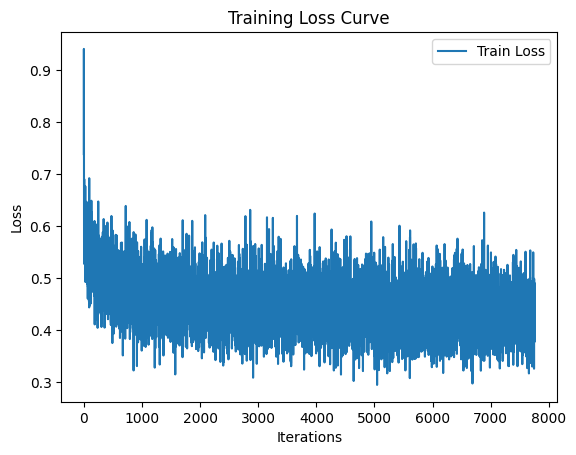

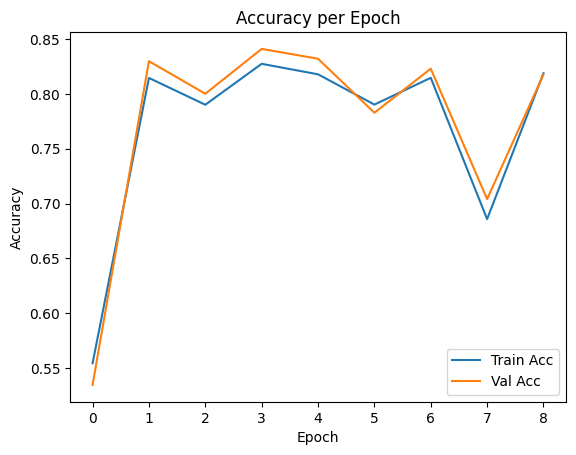

Final Training Accuracy: 0.8189
Final Validation Accuracy: 0.8177
Total Time: 135.17s
Time per Epoch: 15.02s


In [ ]:
# DROPOUT 0.5
breastnet7 = BreastNet()
train(model=breastnet7, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

# Conclusion: 0.2 was the best

# Model is generalizing well but we might have reached max capacity of model. Let's add one layer

In [ ]:
class BreastNet(nn.Module):
    def __init__(self):
        super(BreastNet, self).__init__()
        self.name = "BreastNet"

        # 5 Convolutional Blocks (all with padding=1)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn_conv1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn_conv2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn_conv3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn_conv4 = nn.BatchNorm2d(256)

        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn_conv5 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)
        self.activation = nn.SiLU()

        self.final_spatial_dim = self.compute_feature_map_size(50)

        # input size 512 channels
        self.fc1 = nn.Linear(512 * self.final_spatial_dim * self.final_spatial_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(512, 2)

    def compute_feature_map_size(self, input_size):
        size = input_size
        for _ in range(4):
            size = size // 2
        return size

    def forward(self, x):
        x = self.pool(self.activation(self.bn_conv1(self.conv1(x))))
        x = self.pool(self.activation(self.bn_conv2(self.conv2(x))))
        x = self.pool(self.activation(self.bn_conv3(self.conv3(x))))
        x = self.pool(self.activation(self.bn_conv4(self.conv4(x))))
        x = self.activation(self.bn_conv5(self.conv5(x)))

        x = x.view(x.size(0), -1)
        x = self.bn1(self.fc1(x))
        x = self.dropout(self.activation(x))
        x = self.fc2(x)
        return x

Epoch 1/30: 100%|██████████| 862/862 [00:11<00:00, 74.78it/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:243: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)



Epoch 0 Finished.
  Train Accuracy:      0.8037
  Validation Accuracy: 0.8279


Epoch 2/30: 100%|██████████| 862/862 [00:11<00:00, 74.88it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8178
  Validation Accuracy: 0.8082


Epoch 3/30: 100%|██████████| 862/862 [00:11<00:00, 77.95it/s]


...


Epoch 10 Finished.
  Train Accuracy:      0.8479
  Validation Accuracy: 0.8453


Epoch 12/30: 100%|██████████| 862/862 [00:11<00:00, 77.84it/s]



Epoch 11 Finished.
  Train Accuracy:      0.8343
  Validation Accuracy: 0.8407


Epoch 13/30: 100%|██████████| 862/862 [00:11<00:00, 77.36it/s]



Epoch 12 Finished.
  Train Accuracy:      0.8458
  Validation Accuracy: 0.8495
Early stopping on epoch 12 (no improvement in 5 epochs)!


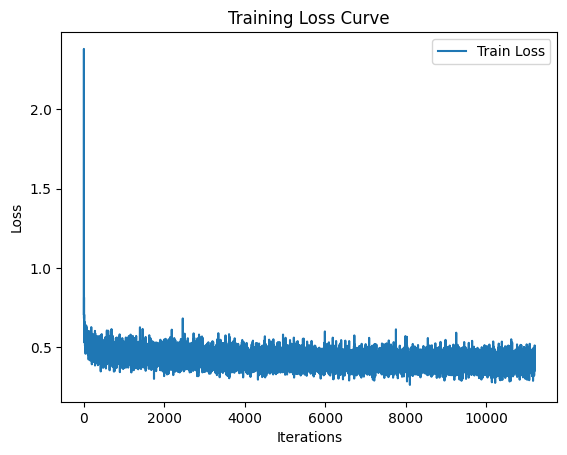

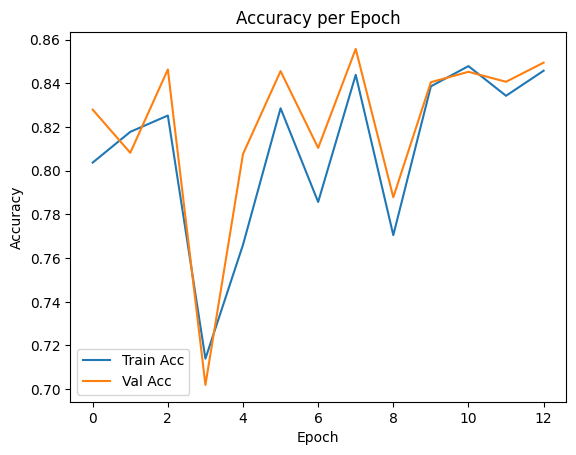

Final Training Accuracy: 0.8458
Final Validation Accuracy: 0.8495
Total Time: 230.70s
Time per Epoch: 17.75s


In [ ]:
breastnet1 = BreastNet()
train(model=breastnet1, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

Epoch 1/30: 100%|██████████| 862/862 [00:11<00:00, 77.68it/s]



Epoch 0 Finished.
  Train Accuracy:      0.8038
  Validation Accuracy: 0.8257


Epoch 2/30: 100%|██████████| 862/862 [00:11<00:00, 76.75it/s]



Epoch 1 Finished.
  Train Accuracy:      0.7999
  Validation Accuracy: 0.8192


Epoch 3/30: 100%|██████████| 862/862 [00:11<00:00, 75.57it/s]


...


Epoch 9 Finished.
  Train Accuracy:      0.8328
  Validation Accuracy: 0.8310


Epoch 11/30: 100%|██████████| 862/862 [00:11<00:00, 76.06it/s]



Epoch 10 Finished.
  Train Accuracy:      0.7720
  Validation Accuracy: 0.8097


Epoch 12/30: 100%|██████████| 862/862 [00:11<00:00, 76.20it/s]



Epoch 11 Finished.
  Train Accuracy:      0.8033
  Validation Accuracy: 0.8167
Early stopping on epoch 11 (no improvement in 7 epochs)!


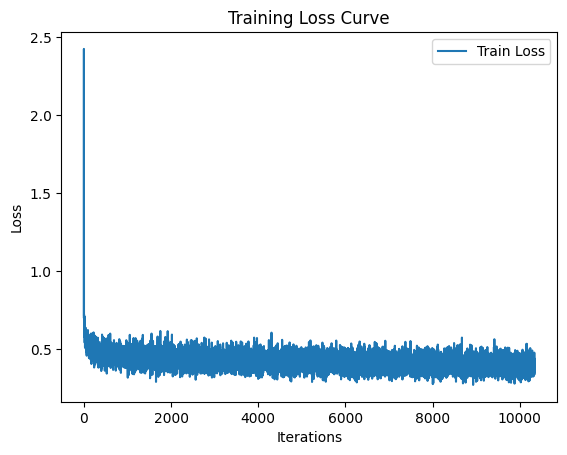

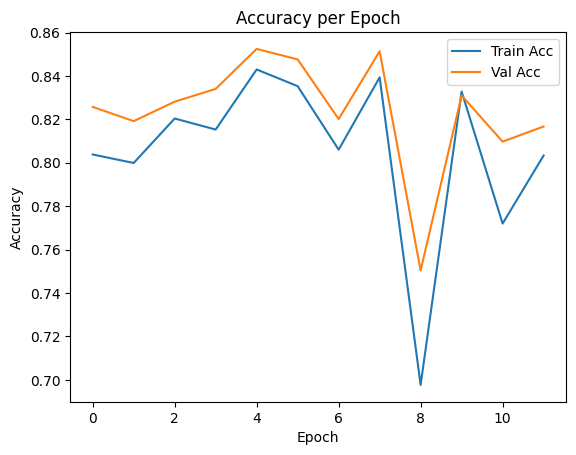

Final Training Accuracy: 0.8033
Final Validation Accuracy: 0.8167
Total Time: 213.26s
Time per Epoch: 17.77s


In [ ]:
# Patience 7 and dropout 0.1 again
breastnet1 = BreastNet()
train(model=breastnet1, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

### Model is still generalizing well but can't get past that point, so I will add a third fc layer

In [ ]:
class BreastNet(nn.Module):
    def __init__(self):
        super(BreastNet, self).__init__()
        self.name = "BreastNet"

        # 6 Convolutional layers with padding=1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn_conv1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn_conv2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn_conv3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn_conv4 = nn.BatchNorm2d(256)

        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn_conv5 = nn.BatchNorm2d(512)

        self.conv6 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn_conv6 = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)
        self.activation = nn.SiLU()

        self.final_spatial_dim = self.compute_feature_map_size(50)

        # FC Layers
        flattened_size = 512 * self.final_spatial_dim * self.final_spatial_dim
        self.fc1 = nn.Linear(flattened_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.1)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.4)

        self.fc3 = nn.Linear(256, 2)

    def compute_feature_map_size(self, input_size):
        size = input_size
        for _ in range(4):
            size = size // 2
        return size

    def forward(self, x):
        x = self.pool(self.activation(self.bn_conv1(self.conv1(x))))
        x = self.pool(self.activation(self.bn_conv2(self.conv2(x))))
        x = self.pool(self.activation(self.bn_conv3(self.conv3(x))))
        x = self.pool(self.activation(self.bn_conv4(self.conv4(x))))
        x = self.activation(self.bn_conv5(self.conv5(x)))
        x = self.activation(self.bn_conv6(self.conv6(x)))

        x = x.view(x.size(0), -1)

        x = self.dropout1(self.activation(self.bn1(self.fc1(x))))
        x = self.dropout2(self.activation(self.bn2(self.fc2(x))))
        x = self.fc3(x)
        return x

In [ ]:
breastnet1 = BreastNet()
train(model=breastnet1, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

Epoch 1/10: 100%|██████████| 862/862 [25:37<00:00,  1.78s/it]


# Model became too unstable, added one more convolutional layer

Epoch 1/30: 100%|██████████| 862/862 [00:25<00:00, 33.35it/s]



Epoch 0 Finished.
  Train Accuracy:      0.8212
  Validation Accuracy: 0.8293


Epoch 2/30: 100%|██████████| 862/862 [00:26<00:00, 33.04it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8049
  Validation Accuracy: 0.8291


Epoch 3/30: 100%|██████████| 862/862 [00:25<00:00, 33.54it/s]


...


Epoch 17 Finished.
  Train Accuracy:      0.8904
  Validation Accuracy: 0.8370


Epoch 19/30: 100%|██████████| 862/862 [00:25<00:00, 33.44it/s]



Epoch 18 Finished.
  Train Accuracy:      0.8824
  Validation Accuracy: 0.8356


Epoch 20/30: 100%|██████████| 862/862 [00:26<00:00, 33.15it/s]



Epoch 19 Finished.
  Train Accuracy:      0.9093
  Validation Accuracy: 0.8470
Early stopping on epoch 19 (no improvement in 7 epochs)!


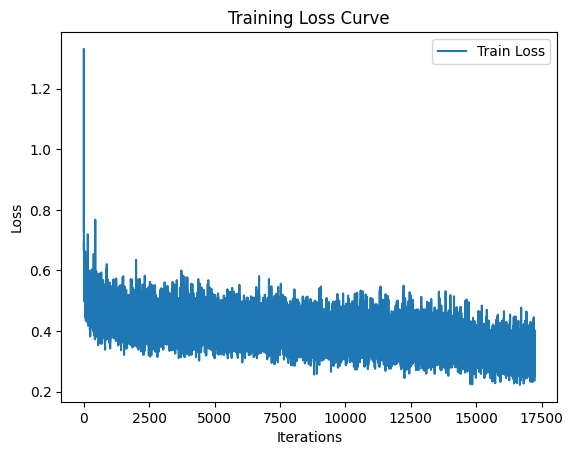

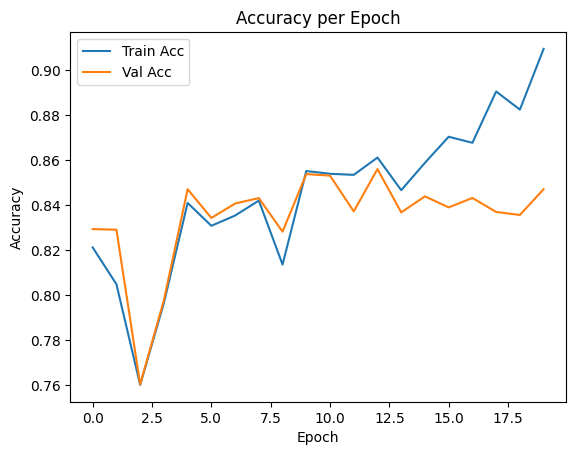

Final Training Accuracy: 0.9093
Final Validation Accuracy: 0.8470
Total Time: 760.69s
Time per Epoch: 38.03s


In [ ]:
breastnet1 = BreastNet()
train(model=breastnet1, train_loader=train_loader, val_loader=val_loader,lr=0.002, print_stat=1)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 1/50: 100%|██████████| 862/862 [00:13<00:00, 65.39it/s]



Epoch 0 Finished.
  Train Accuracy:      0.7449
  Validation Accuracy: 0.7389


Epoch 2/50: 100%|██████████| 862/862 [00:13<00:00, 64.86it/s]



Epoch 1 Finished.
  Train Accuracy:      0.8206
  Validation Accuracy: 0.8366


Epoch 3/50: 100%|██████████| 862/862 [00:13<00:00, 65.74it/s]


...


Epoch 12 Finished.
  Train Accuracy:      0.8590
  Validation Accuracy: 0.8491


Epoch 14/50: 100%|██████████| 862/862 [00:13<00:00, 65.07it/s]



Epoch 13 Finished.
  Train Accuracy:      0.8588
  Validation Accuracy: 0.8532


Epoch 15/50: 100%|██████████| 862/862 [00:13<00:00, 65.55it/s]



Epoch 14 Finished.
  Train Accuracy:      0.8479
  Validation Accuracy: 0.8273
Early stopping on epoch 14 (no improvement in 7 epochs)!


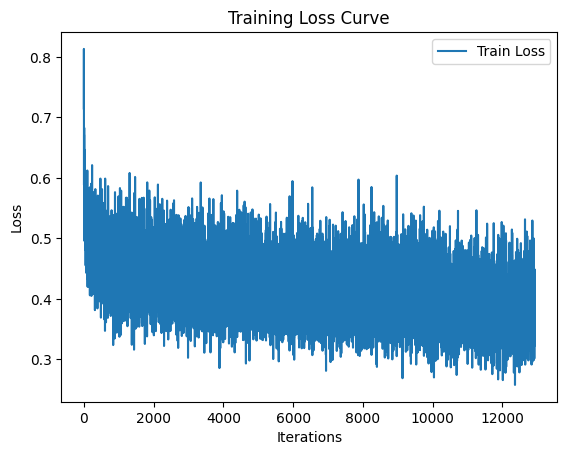

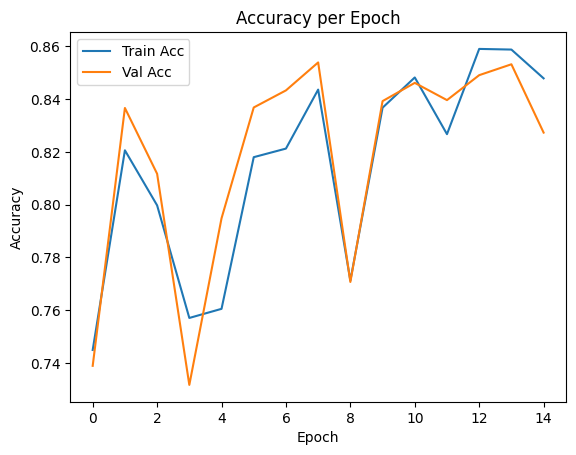

Final Training Accuracy: 0.8479
Final Validation Accuracy: 0.8273
Total Time: 301.62s
Time per Epoch: 20.11s


In [ ]:
breastnet2 = BreastNet()
train(model=breastnet2, train_loader=train_loader, val_loader=val_loader,lr=0.002, num_epochs=50, print_stat=1)

In [ ]:
drive.mount('/content/drive')
!ls "/content/drive/MyDrive/APS360 Project/Dataset"

Mounted at /content/drive
test  train  val


In [ ]:
# Save model
torch.save(breastnet1.state_dict(), '/content/drive/MyDrive/APS360 Project/Model Checkpoints/best_breastnet.pth')

In [ ]:
# Load model
breastnet1 = BreastNet()
breastnet1.load_state_dict(torch.load('/content/drive/MyDrive/APS360 Project/Model Checkpoints/best_breastnet.pth'))

<All keys matched successfully>

# Get metrics

In [ ]:
# Load best model so far
best_so_far = breastnet1

# Test accuracy
correct = 0
total = 0
for imgs, labels in test_loader:

    # Enable CUDA
    if torch.cuda.is_available():
          imgs = imgs.cuda()
          labels = labels.cuda()
          best_so_far = best_so_far.cuda()

    output = best_so_far(imgs)
    pred = output.max(1, keepdim=True)[1]
    correct += pred.eq(labels.view_as(pred)).sum().item()
    total += imgs.shape[0]
print('Accuracy on test data: ', correct / total)

Accuracy on test data:  0.8330689173753014


Using device: cuda


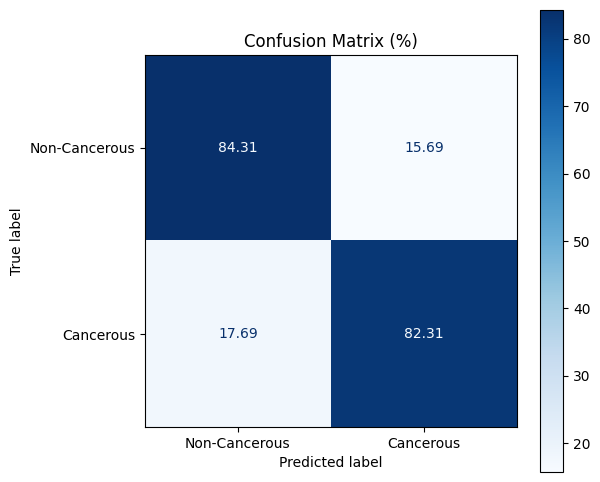

RMSE: 0.4086
Sensitivity (Recall): 0.8231
Specificity: 0.8431
F1 Score: 0.8314


In [ ]:
# Calculate other metrics
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

best_so_far.to(device)
best_so_far.eval()

all_predictions = []
all_labels = []

# Process test set in batches
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        preds = torch.argmax(best_so_far(imgs), dim=1)

        # Move back to CPU after getting preds
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert lists to numpy arrays
predictions = np.array(all_predictions)
labels = np.array(all_labels)

# Compute confusion matrix
cm = confusion_matrix(labels, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
disp = ConfusionMatrixDisplay(cm_normalized, display_labels=["Non-Cancerous", "Cancerous"])

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")
plt.title("Confusion Matrix (%)")
plt.show()

# Extract TP, TN, FP, FN from confusion matrix
tn, fp, fn, tp = cm.ravel()

# Compute RMSE, sensitivity, specificity, and F1
rmse = np.sqrt(mean_squared_error(labels, predictions))
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = f1_score(labels, predictions)

print(f"RMSE: {rmse:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")

# Reconstructing the image

First, we will get all the images of a random patient

In [ ]:
patient_images = []
list_of_patients = os.listdir(path)
random_patient = '13462'
patient_path = os.path.join(path, random_patient)
print(patient_path)
for label in ['0', '1']:
    label_path = os.path.join(patient_path, label)
    if os.path.isdir(label_path):
        for file_name in os.listdir(label_path):
            file_path = os.path.join(label_path, file_name)
            patient_images.append(file_path)

NameError: name 'os' is not defined

###Aux function to parse coordinates and label from image files

In [ ]:
def extract_patch_info(file_path):
    filename = os.path.basename(file_path)
    parts = filename.split("_")
    x = int(parts[2][1:])
    y = int(parts[3][1:])
    label = int(parts[4][-5])
    return x, y, label

In [ ]:
def reconstruct_patient(model, patient_path, transform, use_predictions=True):
    # Gather all patch paths
    patient_images = []
    for label in ['0', '1']:
        label_path = os.path.join(patient_path, label)
        if os.path.isdir(label_path):
            for file_name in os.listdir(label_path):
                patient_images.append(os.path.join(label_path, file_name))

    # Get patch size
    sample_patch = Image.open(patient_images[0])
    patch_width, patch_height = sample_patch.size

    # Determine canvas size
    max_x = max_y = 0
    for img_path in patient_images:
        x, y, _ = extract_patch_info(img_path)
        max_x = max(max_x, x)
        max_y = max(max_y, y)

    canvas_width = max_x + patch_width
    canvas_height = max_y + patch_height

    gt_canvas = Image.new("RGBA", (canvas_width, canvas_height), color=(0, 0, 0, 0))
    pred_canvas = Image.new("RGBA", (canvas_width, canvas_height), color=(0, 0, 0, 0))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    for img_path in patient_images:
        x, y, true_label = extract_patch_info(img_path)
        patch = Image.open(img_path).convert("RGB")

        gt_patch = patch.copy()
        if true_label == 1:
            red_overlay = Image.new("RGB", patch.size, color=(255, 0, 0))
            gt_patch = Image.blend(gt_patch, red_overlay, alpha=0.5)
        gt_canvas.paste(gt_patch, (x, y))

        pred_patch = patch.copy()
        if use_predictions:
            input_tensor = transform(pred_patch).unsqueeze(0).to(device)

            with torch.no_grad():
                logits = model(input_tensor)
                probs = torch.softmax(logits, dim=1)
                cancer_prob = probs[0, 1].item()

            if cancer_prob > 0.8:
                overlay = Image.new("RGB", patch.size, color=(0, 0, 255))
                pred_patch = Image.blend(pred_patch, overlay, alpha=0.5)
        pred_canvas.paste(pred_patch, (x, y))

    return gt_canvas, pred_canvas

Make sure width and height are 50 pixels

In [ ]:
sample_patch = Image.open(patient_images[0])
patch_width, patch_height = sample_patch.size

print(patch_height)
print(patch_width)

50
50


This gives us the dimensions our final output will have

In [ ]:
max_x = max_y = 0
for img_path in patient_images:
    x, y, _ = extract_patch_info(img_path)
    max_x = max(max_x, x)
    max_y = max(max_y, y)

# Total size needed
canvas_width = max_x + patch_width
canvas_height = max_y + patch_height

print(canvas_width)
print(canvas_height)

3551
2801


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import torch

def calculate_metrics(model, data_loader, device):

    model.to(device)
    model.eval()

    all_predictions = []
    all_labels = []

    # Process test set in batches
    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            preds = torch.argmax(model(imgs), dim=1)

            # Move back to CPU after getting preds
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    predictions = np.array(all_predictions)
    labels = np.array(all_labels)

    # Compute confusion matrix
    cm = confusion_matrix(labels, predictions)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    disp = ConfusionMatrixDisplay(cm_normalized, display_labels=["Non-Cancerous", "Cancerous"])

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f")
    plt.title("Confusion Matrix (%)")
    plt.show()

    tn, fp, fn, tp = cm.ravel()

    # Compute accuracy
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    print(f"Accuracy: {accuracy:.4f}")

    rmse = np.sqrt(mean_squared_error(labels, predictions))
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = f1_score(labels, predictions)

    print(f"RMSE: {rmse:.4f}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score: {f1:.4f}")

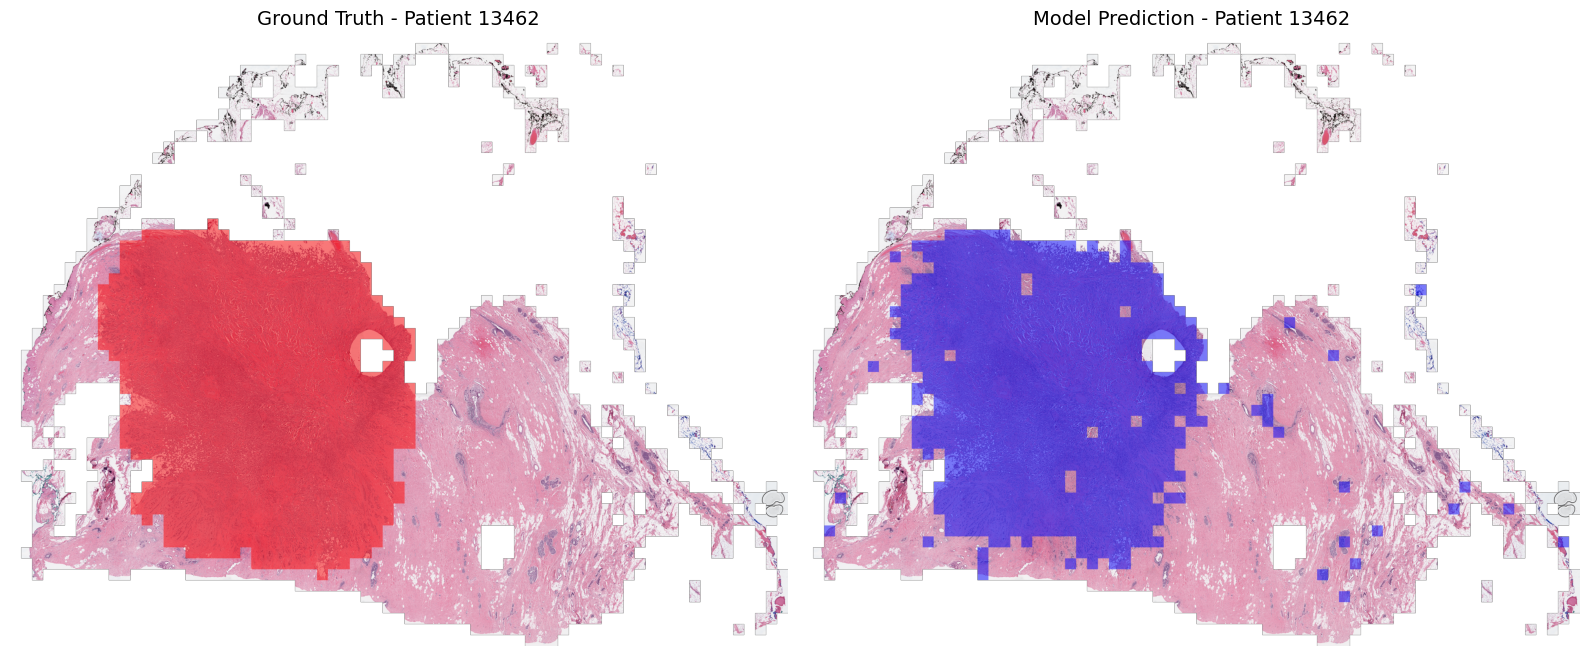

In [ ]:
# Define transform
transform = transforms.Compose([
  transforms.RandomRotation(degrees=(-15, 15)),
  transforms.RandomHorizontalFlip(p=0.5),
  transforms.RandomVerticalFlip(p=0.5),
  transforms.RandomResizedCrop(size=50, scale=(0.8, 1.0)),
  transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
  transforms.ToTensor(),
  transforms.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3))
])

# Generate images
gt_image, pred_image = reconstruct_patient(best_so_far, patient_path, transform)

# Plot side-by-side
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(gt_image)
plt.axis('off')
plt.title(f"Ground Truth - Patient {random_patient}", fontsize=14)

plt.subplot(1, 2, 2)
plt.imshow(pred_image)
plt.axis('off')
plt.title(f"Model Prediction - Patient {random_patient}", fontsize=14)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


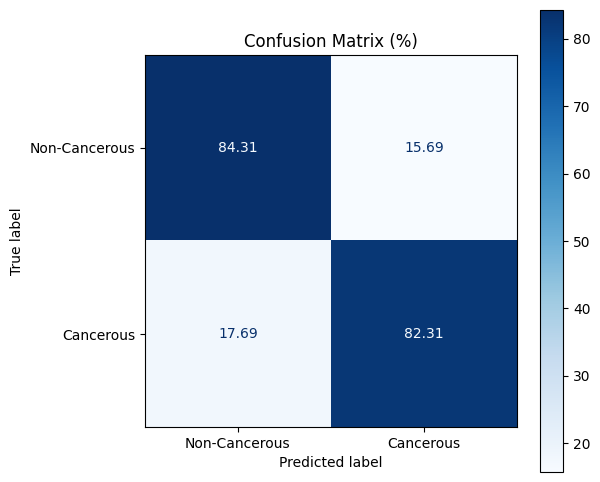

Accuracy: 0.8331
RMSE: 0.4086
Sensitivity (Recall): 0.8231
Specificity: 0.8431
F1 Score: 0.8314


In [ ]:
calculate_metrics(best_so_far, test_loader, device)